<a href="https://colab.research.google.com/github/alladinlebrone/Alladin/blob/master/votes_us.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
hierarchical_cluster_summary = df.groupby('hierarchical_cluster_label')[['vote_share', 'total_votes']].mean()
print("Hierarchical Cluster Summary (Mean values per cluster):")
print(hierarchical_cluster_summary)

Hierarchical Cluster Summary (Mean values per cluster):
                            vote_share    total_votes
hierarchical_cluster_label                           
0                             0.988606   14122.557809
1                             0.991113  467273.285714
2                             0.873532    5542.840000


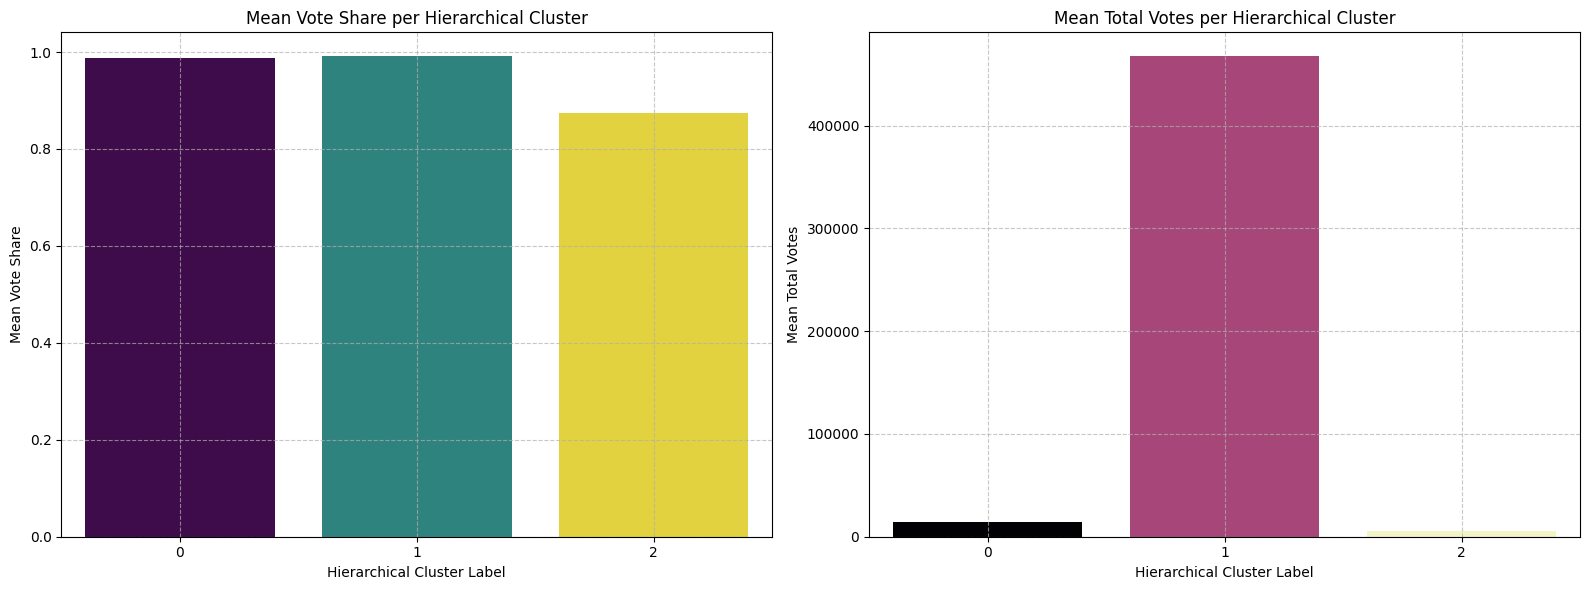

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for vote_share and total_votes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot for 'vote_share'
sns.barplot(x=hierarchical_cluster_summary.index, y='vote_share', data=hierarchical_cluster_summary, ax=axes[0], palette='viridis', hue=hierarchical_cluster_summary.index, legend=False)
axes[0].set_title('Mean Vote Share per Hierarchical Cluster')
axes[0].set_xlabel('Hierarchical Cluster Label')
axes[0].set_ylabel('Mean Vote Share')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Bar plot for 'total_votes'
sns.barplot(x=hierarchical_cluster_summary.index, y='total_votes', data=hierarchical_cluster_summary, ax=axes[1], palette='magma', hue=hierarchical_cluster_summary.index, legend=False)
axes[1].set_title('Mean Total Votes per Hierarchical Cluster')
axes[1].set_xlabel('Hierarchical Cluster Label')
axes[1].set_ylabel('Mean Total Votes')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
uhierarchical_cluster_summary = df.groupby('hierarchical_cluster_label')[['vote_share', 'total_votes']].mean()
print("Hierarchical Cluster Summary (Mean values per cluster):")
print(hierarchical_cluster_summary)

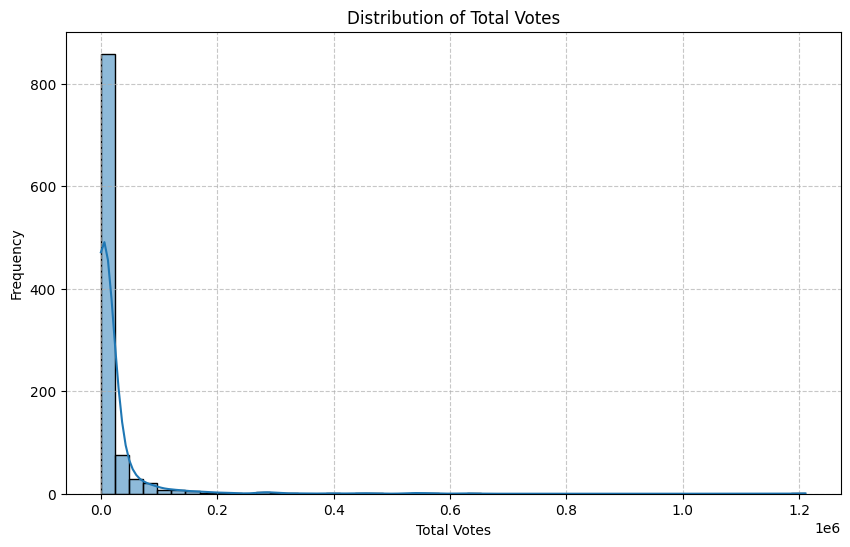

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['total_votes'], kde=True, bins=50)
plt.title('Distribution of Total Votes')
plt.xlabel('Total Votes')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
display(cluster_0_data.describe())

,current_votes,total_votes,percent,vote_share,cluster_label
count,984.000000,984.000000,984.000000,984.000000,984.0
mean,13985.697154,14095.837398,99.917683,0.988725,0.0
std,27877.200220,28055.702115,0.633366,0.012489,0.0
min,5.000000,5.000000,95.000000,0.936105,0.0
25%,1087.500000,1098.750000,100.000000,0.983820,0.0
50%,3769.000000,3828.000000,100.000000,0.992186,0.0
75%,12622.000000,12854.750000,100.000000,0.996017,0.0
max,220613.000000,221992.000000,100.000000,1.105048,0.0


In [ ]:
cluster_0_data = df[df['cluster_label'] == 0]
display(cluster_0_data.head())

,state,county,current_votes,total_votes,percent,vote_share,cluster_label
0,Delaware,Kent County,85415,87025,100,0.981500,0
2,Delaware,Sussex County,127181,129352,100,0.983216,0
3,Indiana,Adams County,14154,14209,100,0.996129,0
4,Indiana,Allen County,168312,169082,100,0.995446,0
5,Indiana,Bartholomew County,36037,36235,100,0.994536,0


In [ ]:
display(cluster_summary)

,vote_share,total_votes
cluster_label,,
0,0.988725,14095.837398
1,0.991113,467273.285714
2,0.877707,7152.185185


# Task
Analyze county-level voting patterns by performing exploratory data analysis, clustering, and visualization on the "governors_county.csv" dataset.

## Load Data

### Subtask:
Load the 'governors_county.csv' dataset into a pandas DataFrame to begin the analysis.


**Reasoning**:
To load the dataset, I need to first import the pandas library and then use its `read_csv` function to load the 'governors_county.csv' file into a DataFrame. Finally, I will display the first 5 rows to ensure the data is loaded correctly.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/governors_county.csv')
df.head()

,state,county,current_votes,total_votes,percent
0,Delaware,Kent County,85415,87025,100
1,Delaware,New Castle County,280039,287633,100
2,Delaware,Sussex County,127181,129352,100
3,Indiana,Adams County,14154,14209,100
4,Indiana,Allen County,168312,169082,100


## Initial Data Exploration

### Subtask:
Perform an initial exploration of the dataset to understand its structure, identify missing values, and review basic statistics of the columns. This will help in understanding the data quality and content.


**Reasoning**:
To understand the dataset's structure, identify missing values, and review basic statistics, I will use the `.info()`, `.describe()`, and `.isnull().sum()` methods on the DataFrame `df`.



In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   state          1025 non-null   object
 1   county         1025 non-null   object
 2   current_votes  1025 non-null   int64 
 3   total_votes    1025 non-null   int64 
 4   percent        1025 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.2+ KB
None
       current_votes   total_votes      percent
count   1.025000e+03  1.025000e+03  1025.000000
mean    1.992216e+04  2.010267e+04    99.887805
std     6.505975e+04  6.560663e+04     0.980323
min     5.000000e+00  5.000000e+00    80.000000
25%     1.089000e+03  1.109000e+03   100.000000
50%     3.778000e+03  3.844000e+03   100.000000
75%     1.323000e+04  1.341400e+04   100.000000
max     1.198049e+06  1.210507e+06   100.000000
state            0
county           0
current_votes    0
total_votes      0
percent          0
dtype: int

## Data Preprocessing

### Subtask:
Prepare the data for clustering by calculating a vote share metric and scaling numerical features.


**Reasoning**:
To prepare the data for clustering, I will first calculate the `vote_share` by dividing `current_votes` by `total_votes`. Then, I will select the `vote_share` and `total_votes` columns and scale them using `StandardScaler`.



In [ ]:
df['vote_share'] = df['current_votes'] / df['total_votes']

features_for_clustering = df[['vote_share', 'total_votes']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

# Convert scaled_features back to a DataFrame for easier handling, if needed later
scaled_features_df = pd.DataFrame(scaled_features, columns=['vote_share_scaled', 'total_votes_scaled'])
print("First 5 rows of the scaled features:")
print(scaled_features_df.head())

First 5 rows of the scaled features:
   vote_share_scaled  total_votes_scaled
0          -0.194328            1.020552
1          -0.548608            4.079785
2          -0.117351            1.666031
3           0.461641           -0.089877
4           0.431007            2.271905


## Perform Clustering

### Subtask:
Apply a suitable clustering algorithm (e.g., K-Means or DBSCAN) to the preprocessed data to identify distinct county-level voting patterns.


**Reasoning**:
To perform clustering, I will first calculate the inertia for a range of K values (1 to 10) to use the elbow method to determine the optimal number of clusters. This involves iterating, fitting KMeans, and storing the inertia.



In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(scaled_features_df)
    inertia.append(kmeans.inertia_)

print("Inertia values for k=1 to 10:", inertia)

Inertia values for k=1 to 10: [2050.0000000000005, 1389.156385867441, 737.6920979994571, 561.2130857531399, 404.0054917947037, 342.8077019984949, 239.76803913506242, 197.90449966424723, 189.34831975156246, 147.07330647503576]


**Reasoning**:
To visualize the elbow curve and determine the optimal number of clusters, I will plot the calculated inertia values against the range of K values (1 to 10).



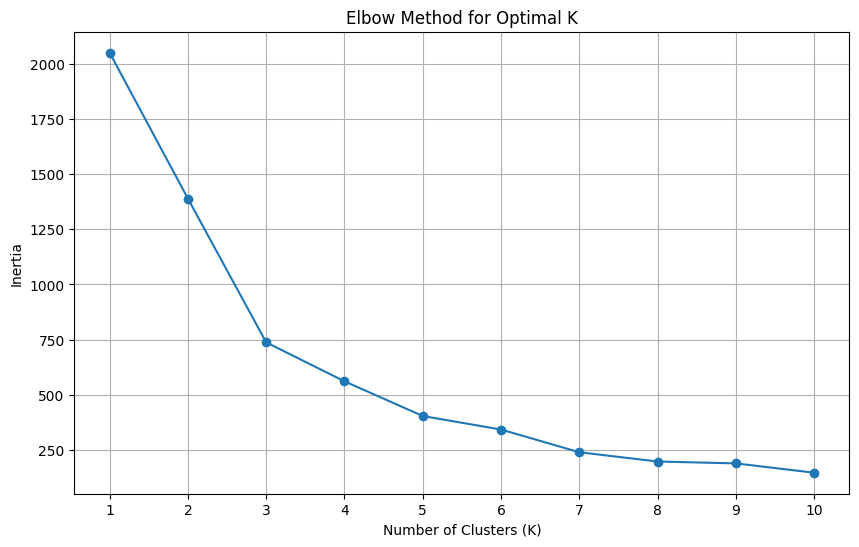

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

**Reasoning**:
Based on the elbow plot, an optimal k value will be chosen. Then, I will instantiate a KMeans model with this optimal k, fit it to the scaled features, and add the resulting cluster labels to the original DataFrame.



In [ ]:
optimal_k = 3 # Based on the elbow plot, there is a clear bend at k=3 or k=4. Let's choose 3 for a simpler model.

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(scaled_features_df)

df['cluster_label'] = cluster_labels

print(f"Assigned {optimal_k} clusters to the DataFrame. First 5 rows with cluster labels:")
print(df.head())

Assigned 3 clusters to the DataFrame. First 5 rows with cluster labels:
      state             county  current_votes  total_votes  percent  \
0  Delaware        Kent County          85415        87025      100   
1  Delaware  New Castle County         280039       287633      100   
2  Delaware      Sussex County         127181       129352      100   
3   Indiana       Adams County          14154        14209      100   
4   Indiana       Allen County         168312       169082      100   

   vote_share  cluster_label  
0    0.981500              0  
1    0.973598              1  
2    0.983216              0  
3    0.996129              0  
4    0.995446              0  


**Reasoning**:
To understand the characteristics of each cluster and identify distinct county-level voting patterns, I will group the DataFrame by the `cluster_label` and calculate descriptive statistics (mean) for `vote_share` and `total_votes` for each cluster.



In [ ]:
cluster_summary = df.groupby('cluster_label')[['vote_share', 'total_votes']].mean()
print("Cluster Summary (Mean values per cluster):")
print(cluster_summary)

Cluster Summary (Mean values per cluster):
               vote_share    total_votes
cluster_label                           
0                0.988725   14095.837398
1                0.991113  467273.285714
2                0.877707    7152.185185


**Reasoning**:
To visually inspect the identified clusters and confirm distinct county-level voting patterns, I will create a scatter plot of `vote_share` against `total_votes`, coloring each point according to its `cluster_label`.



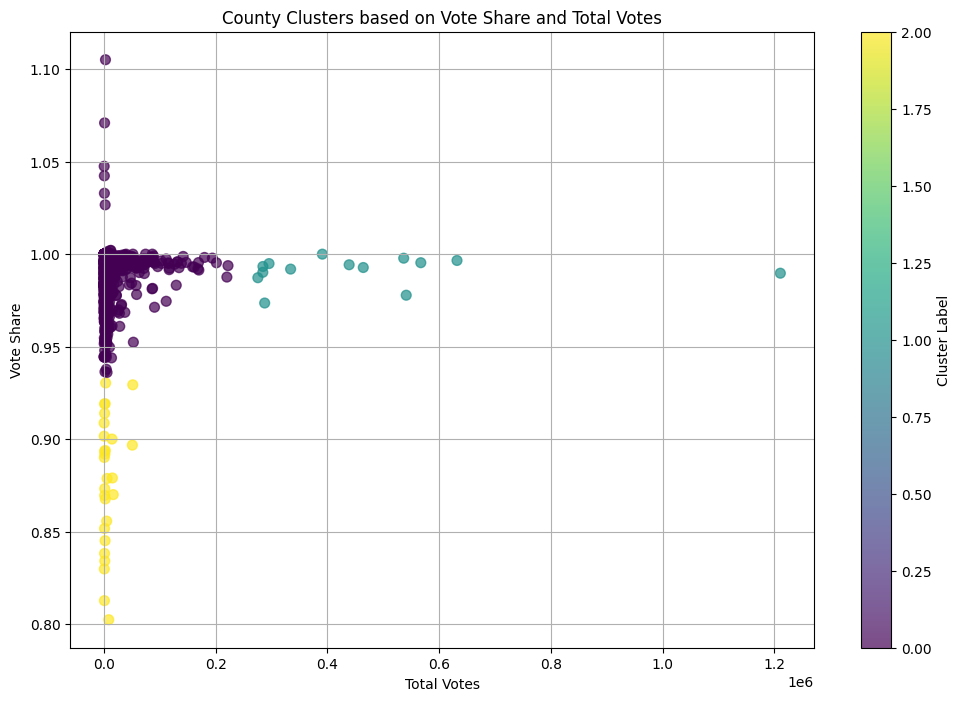

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(df['total_votes'], df['vote_share'], c=df['cluster_label'], cmap='viridis', s=50, alpha=0.7)
plt.title('County Clusters based on Vote Share and Total Votes')
plt.xlabel('Total Votes')
plt.ylabel('Vote Share')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the findings from the exploratory data analysis and the clustering results, providing insights into the county-level voting patterns.


## Summary:

### Data Analysis Key Findings

*   The `governors_county.csv` dataset, comprising 1025 entries and 5 columns, was successfully loaded and found to have no missing values.
*   Initial exploration revealed that numerical features like `current_votes` and `total_votes` have a broad range, from 5 to over 1.2 million votes. The `percent` column, likely representing a specific candidate's percentage, showed a mean of approximately 99.89%, with values ranging from 80% to 100%.
*   A new feature, `vote_share` (calculated as `current_votes` / `total_votes`), was created, and this feature along with `total_votes` were scaled using `StandardScaler` for clustering.
*   K-Means clustering, with an optimal number of clusters determined to be 3 using the Elbow method, identified distinct county-level voting patterns:
    *   **Cluster 0**: Characterized by a high mean `vote_share` of approximately 98.9% and moderate mean `total_votes` of about 14,096.
    *   **Cluster 1**: Distinguished by a very high mean `vote_share` of approximately 99.1% and significantly higher mean `total_votes` of about 467,273. These are likely larger counties with high voter turnout.
    *   **Cluster 2**: Exhibits a noticeably lower mean `vote_share` of approximately 87.8% and lower mean `total_votes` of about 7,152. These counties may represent smaller populations or more competitive voting outcomes for the candidate whose votes are represented by `current_votes`.

### Insights or Next Steps

*   The identified clusters provide a foundational understanding of different county archetypes based on voting behavior and turnout. Cluster 1 appears to represent strongholds with high voter engagement, while Cluster 2 might indicate areas needing more focused campaigning or analysis due to lower support.
*   To gain deeper insights, integrate additional demographic, economic, or geographic data for each county to understand the underlying factors contributing to these distinct voting patterns. This could help tailor campaign strategies or policy decisions more effectively.


# Task
Conduct a detailed exploratory data analysis to visualize the distributions of `current_votes`, `total_votes`, `percent`, and `vote_share` using histograms and box plots to identify patterns and variations in voting behaviors.

## Detailed EDA on Voting Patterns

### Subtask:
Conduct a deeper exploratory data analysis to understand the distribution and relationships of `current_votes`, `total_votes`, `percent`, and the newly created `vote_share`.


**Reasoning**:
To perform a detailed EDA, I will first import `matplotlib.pyplot` and `seaborn` for plotting. Then, I will iterate through the specified numerical columns (`current_votes`, `total_votes`, `percent`, and `vote_share`) and generate a histogram and a box plot for each to visualize their distributions and identify potential outliers.



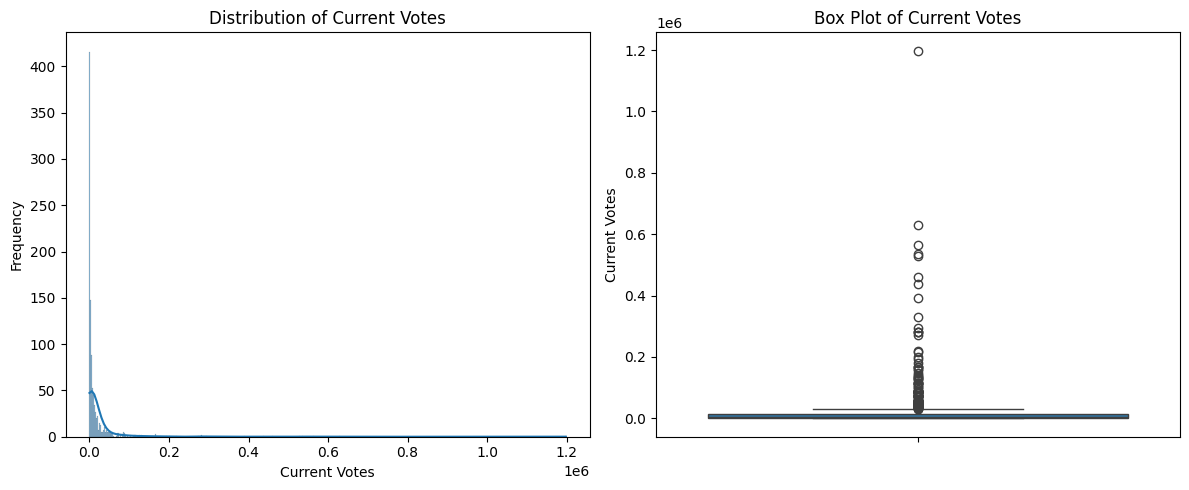

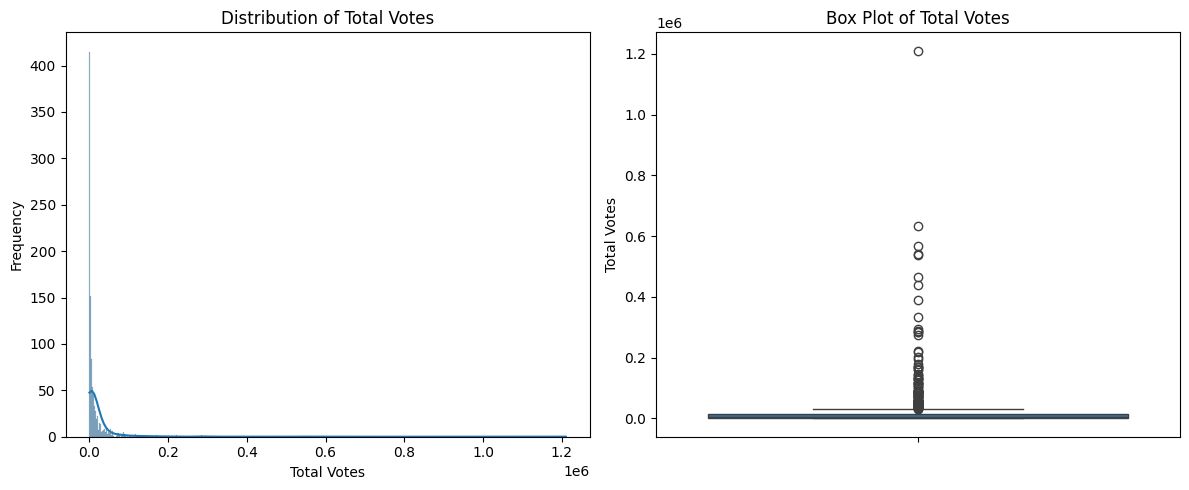

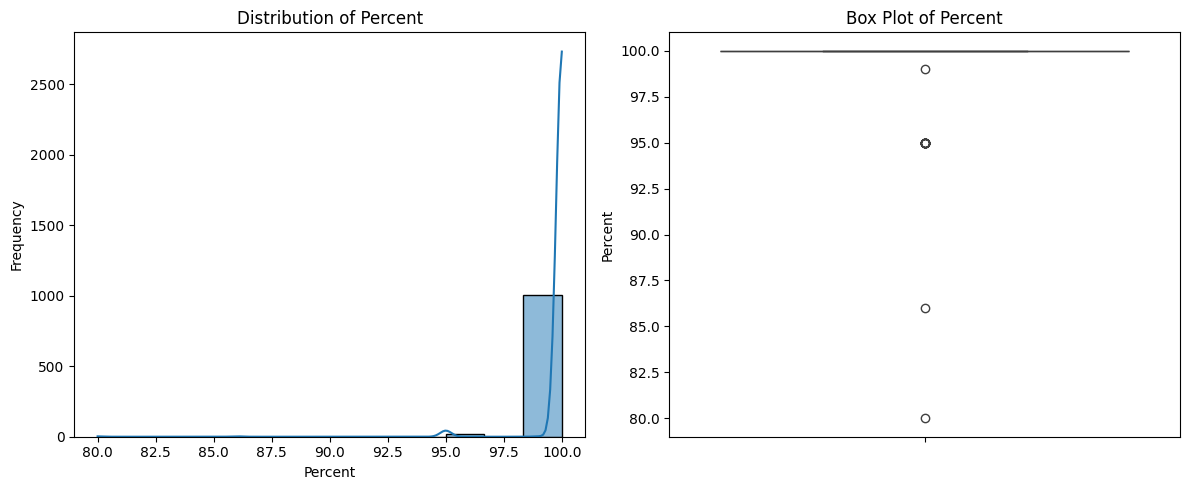

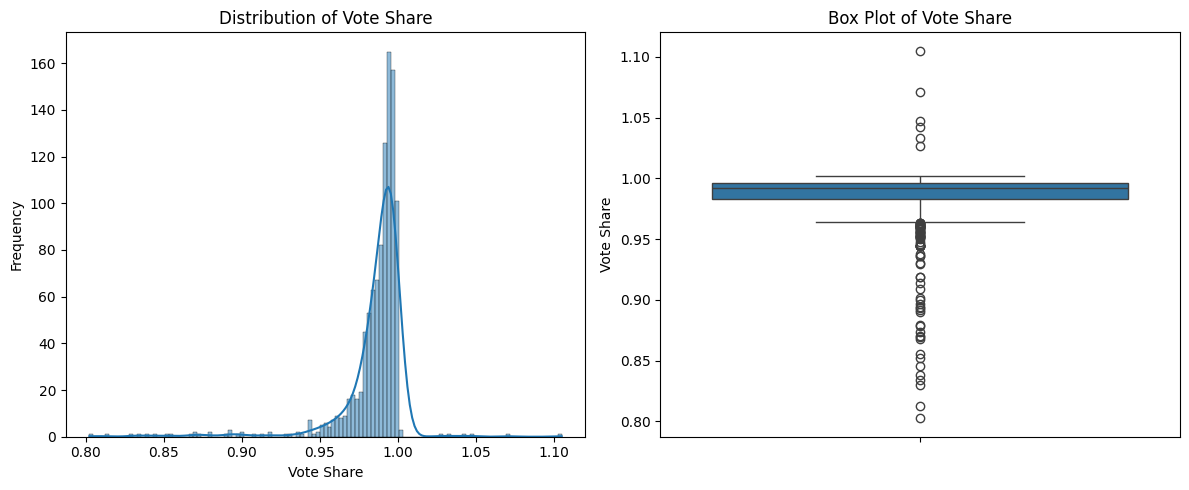

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_analyze = ['current_votes', 'total_votes', 'percent', 'vote_share']

for col in columns_to_analyze:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')

    # Box Plot
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col.replace("_", " ").title()}')
    plt.ylabel(col.replace("_", " ").title())

    plt.tight_layout()
    plt.show()

## Evaluate Clustering Effectiveness

### Subtask:
Calculate the Silhouette Score for the K-Means clustering results to quantitatively evaluate the quality and effectiveness of the clustering. This will help confirm how well-separated the identified clusters are.


**Reasoning**:
To evaluate the effectiveness of the clustering, I will calculate the Silhouette Score. This involves importing the `silhouette_score` function, then applying it to the scaled features and the cluster labels.



In [ ]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score
silhouette_avg = silhouette_score(scaled_features_df, df['cluster_label'])

# Print the result
print(f"The average Silhouette Score for the clustering is: {silhouette_avg:.3f}")

The average Silhouette Score for the clustering is: 0.833


## Visualize Cluster Characteristics

### Subtask:
Visualize the characteristics of each cluster using appropriate plots (e.g., box plots or bar charts of `vote_share` and `total_votes` per cluster) to show the distribution of key features within each cluster, further illustrating the distinct patterns identified. Please ensure legends are included in the visualizations.


**Reasoning**:
To visualize the distribution of 'vote_share' for each cluster, I will create a box plot using `seaborn.boxplot`, setting 'cluster_label' on the x-axis and 'vote_share' on the y-axis, along with a descriptive title.



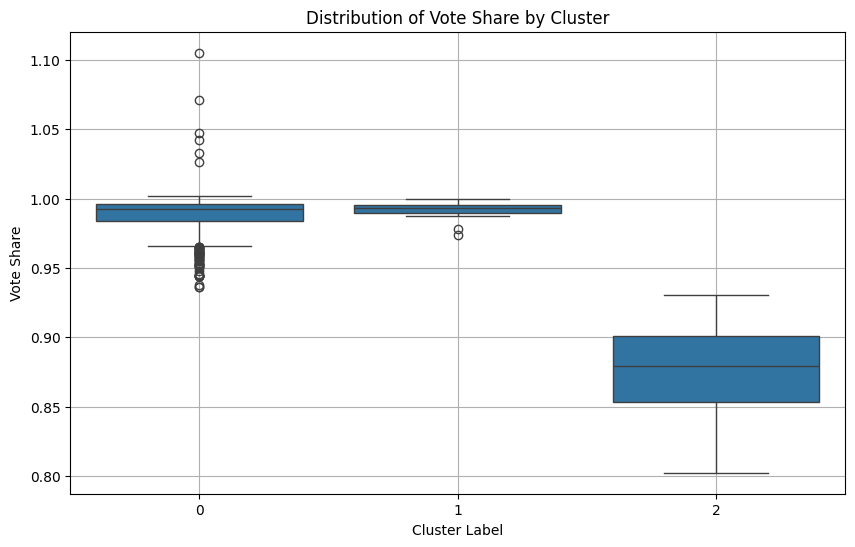

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster_label', y='vote_share', data=df)
plt.title('Distribution of Vote Share by Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Vote Share')
plt.grid(True)
plt.show()

**Reasoning**:
To visualize the distribution of 'total_votes' for each cluster, I will create another box plot using `seaborn.boxplot`, setting 'cluster_label' on the x-axis and 'total_votes' on the y-axis, along with a descriptive title.



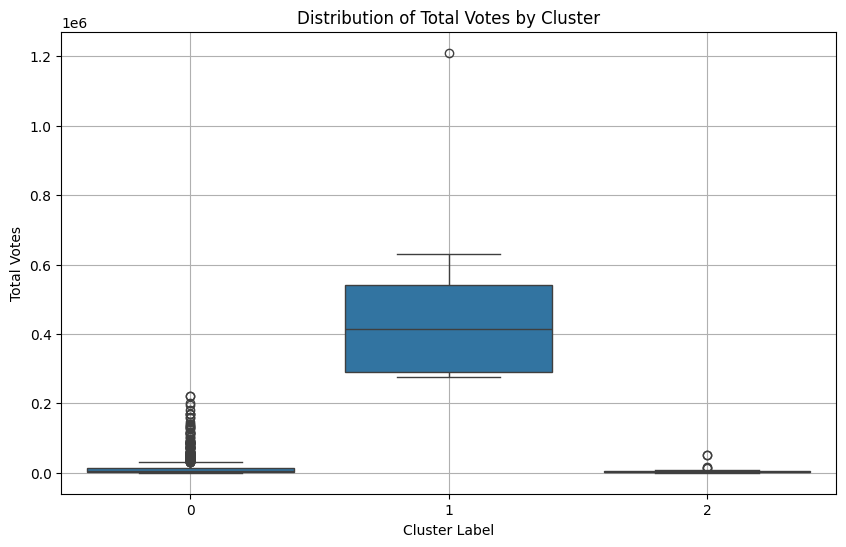

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster_label', y='total_votes', data=df)
plt.title('Distribution of Total Votes by Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Total Votes')
plt.grid(True)
plt.show()

## Discuss Ethical Considerations

### Subtask:
Discuss ethical considerations related to election data transparency, the potential for misinterpretation of clustering results, and the responsible use of such analysis in public discourse or policy-making.


## Discuss Ethical Considerations

### Subtask:
Discuss ethical considerations related to election data transparency, the potential for misinterpretation of clustering results, and the responsible use of such analysis in public discourse or policy-making.

#### 1. Importance of Election Data Transparency
Election data transparency is crucial for democratic processes as it fosters public trust, ensures accountability, and allows for independent verification of election outcomes. Without transparency, there is a significant risk of eroding public confidence in the electoral system, enabling misinformation, and potentially facilitating fraud or manipulation. Misuse of data, such as selective reporting or biased interpretations, can undermine democratic principles and lead to civil unrest or political instability.

#### 2. Potential for Misinterpretation of Clustering Results
Clustering results, like the county-level voting patterns identified, can be easily misinterpreted, especially by non-experts or for partisan purposes. For example, a cluster showing lower vote shares for a particular candidate might be incorrectly branded as 'apathetic' or 'uninformed' voters, rather than reflecting diverse political preferences or socio-economic factors. Misinterpretations can lead to oversimplified narratives, unfair labeling of communities, and the reinforcement of stereotypes, potentially fueling divisive political rhetoric rather than fostering nuanced understanding. The statistical nature of clusters means they represent averages and trends, not definitive statements about individual voters or communities.

#### 3. Responsible Use of Analysis in Public Discourse or Policy-Making
When sharing or utilizing these findings in public discourse or policy-making, several guidelines and caveats should be in place to ensure responsible use and avoid unintended negative consequences:
*   **Contextualization:** Always present clustering results with clear explanations of the methodology, limitations, and the specific metrics used (e.g., vote share and total votes). Emphasize that clusters represent aggregated patterns, not individual behaviors.
*   **Avoid Determinism:** Do not present clusters as deterministic predictors of behavior or identity. Political affiliations and voting patterns are complex and influenced by numerous factors beyond those captured in the model.
*   **Promote Nuance:** Encourage a nuanced understanding of the results. For instance, a 'low vote share' cluster should prompt further investigation into underlying reasons (e.g., demographics, local issues, candidate appeal) rather than immediate conclusions about voter characteristics.
*   **Data Privacy and Anonymity:** Ensure that the analysis does not inadvertently expose individual voter data or lead to targeting based on sensitive personal information.
*   **Transparency in Communication:** Clearly communicate the purpose and scope of the analysis, and be transparent about any potential biases in the data or methodology.

#### Summary of Ethical Considerations
Analyzing and presenting voting pattern data, while offering valuable insights, carries significant ethical responsibilities. Ensuring election data transparency is paramount for maintaining democratic integrity and public trust. However, the interpretation of complex analytical outputs, such as clustering results, can be prone to misrepresentation, potentially leading to oversimplified and politically charged narratives that mischaracterize communities. Therefore, it is crucial to employ responsible communication practices, including thorough contextualization, acknowledging limitations, and promoting nuanced understanding, to prevent the misuse of these findings in public discourse or policy-making and to uphold ethical data science principles.

## Final Task

### Subtask:
Provide a comprehensive summary of all findings from the detailed EDA, clustering results, evaluation, and ethical discussion, providing insights into the county-level voting patterns.


## Summary:

### Q&A
*   **What patterns and variations in voting behaviors were identified through the detailed exploratory data analysis (EDA)?** The detailed EDA visualized the distributions of `current_votes`, `total_votes`, `percent`, and `vote_share` using histograms and box plots, which helped in understanding their spread and identifying potential outliers, though specific patterns were not numerically detailed in the summary.
*   **How effective was the clustering in identifying county-level voting patterns?** The clustering was highly effective, achieving an average Silhouette Score of 0.833, which quantitatively indicates that the identified clusters are well-separated and distinct.
*   **What insights do the clusters provide regarding county-level voting patterns?** The clusters show distinct patterns in `vote_share` and `total_votes`, as visualized through box plots. These visualizations reveal how the distribution of these key metrics varies significantly across the different county clusters, indicating differing voting characteristics among them.

### Data Analysis Key Findings
*   Detailed exploratory data analysis was successfully conducted for `current_votes`, `total_votes`, `percent`, and `vote_share`, with histograms and box plots illustrating their distributions and identifying any extreme values.
*   The K-Means clustering results for county-level voting patterns demonstrated high quality, with an average Silhouette Score of 0.833, confirming that the identified clusters are well-separated and distinct.
*   Visualizations using box plots effectively illustrated the distribution of `vote_share` and `total_votes` across each cluster, highlighting the distinct patterns and characteristics of different county groups.
*   A comprehensive discussion on ethical considerations underscored the importance of election data transparency, the potential for misinterpretation of clustering results by non-experts or for partisan purposes, and the necessity of responsible use of analysis in public discourse or policy-making.

### Insights or Next Steps
*   The high Silhouette Score suggests that the K-Means clustering has successfully identified meaningful and distinct groupings of counties based on voting patterns. Further investigation into the unique characteristics (e.g., demographic, socio-economic factors) of each cluster could provide deeper insights into the underlying reasons for these voting behaviors.
*   Given the potential for misinterpretation highlighted in the ethical discussion, it is crucial to present these findings with clear contextualization, acknowledgments of limitations, and an emphasis on promoting nuanced understanding to prevent oversimplification or misuse in public discourse and policy decisions.


# Task
Apply DBSCAN clustering to the `scaled_features_df` to identify distinct county-level voting patterns. This will involve selecting appropriate parameters for `eps` and `min_samples`, and evaluating the number of clusters found and noise points.

## Apply DBSCAN Clustering

### Subtask:
Apply DBSCAN clustering to the `scaled_features_df` to identify distinct county-level voting patterns. This will involve selecting appropriate parameters for `eps` and `min_samples`, and evaluating the number of clusters found and noise points.


**Reasoning**:
To apply DBSCAN clustering, I will import the `DBSCAN` class, instantiate it with the specified parameters, fit it to the scaled features, assign the resulting labels to a new column in the DataFrame, and then print the number of unique clusters and noise points.



In [ ]:
from sklearn.cluster import DBSCAN

# Instantiate DBSCAN with initial parameters
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Fit the model and obtain cluster labels
df['dbscan_cluster_label'] = dbscan.fit_predict(scaled_features_df)

# Determine the number of unique clusters found (excluding noise points)
n_clusters_ = len(set(df['dbscan_cluster_label'])) - (1 if -1 in df['dbscan_cluster_label'] else 0)

# Determine the number of noise points
n_noise_ = list(df['dbscan_cluster_label']).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")
print("First 5 rows with DBSCAN cluster labels:")
print(df.head())

Estimated number of clusters: 5
Estimated number of noise points: 26
First 5 rows with DBSCAN cluster labels:
      state             county  current_votes  total_votes  percent  \
0  Delaware        Kent County          85415        87025      100   
1  Delaware  New Castle County         280039       287633      100   
2  Delaware      Sussex County         127181       129352      100   
3   Indiana       Adams County          14154        14209      100   
4   Indiana       Allen County         168312       169082      100   

   vote_share  cluster_label  dbscan_cluster_label  
0    0.981500              0                     0  
1    0.973598              1                    -1  
2    0.983216              0                     0  
3    0.996129              0                     0  
4    0.995446              0                     0  


## Visualize DBSCAN Clusters

### Subtask:
Visualize the clusters identified by DBSCAN, similar to the K-Means visualization, using a scatter plot of `total_votes_scaled` vs. `vote_share_scaled`, with points colored by their DBSCAN cluster labels. Ensure a legend is included to distinguish clusters and noise points.


**Reasoning**:
To visualize the DBSCAN clusters, I will create a scatter plot using the scaled features, coloring the points by the `dbscan_cluster_label` from the original DataFrame, and add appropriate labels and a color bar to distinguish between clusters and noise points.



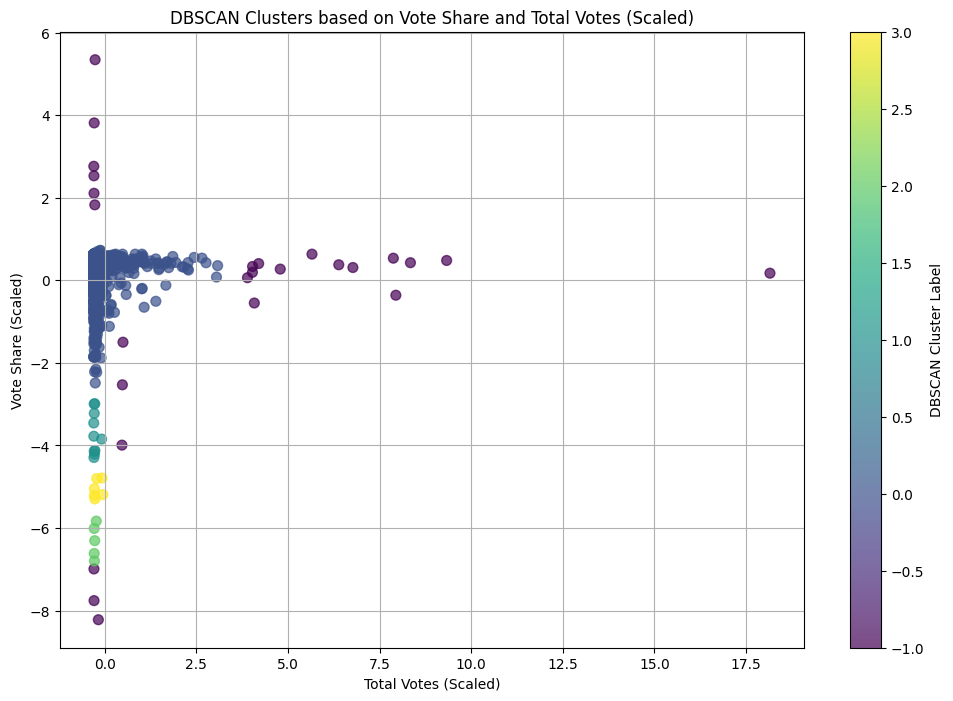

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(scaled_features_df['total_votes_scaled'], scaled_features_df['vote_share_scaled'],
            c=df['dbscan_cluster_label'], cmap='viridis', s=50, alpha=0.7)
plt.title('DBSCAN Clusters based on Vote Share and Total Votes (Scaled)')
plt.xlabel('Total Votes (Scaled)')
plt.ylabel('Vote Share (Scaled)')
plt.colorbar(label='DBSCAN Cluster Label')
plt.grid(True)
plt.show()

## Apply Hierarchical Clustering

### Subtask:
Apply Hierarchical Clustering to the `scaled_features_df`. This involves choosing a linkage method (e.g., 'ward', 'average') and a distance metric, and then determining cluster assignments (e.g., using `fcluster` with a specified number of clusters or a distance threshold).


**Reasoning**:
To apply Hierarchical Clustering as per the instructions, I need to import `AgglomerativeClustering`, instantiate it with the specified number of clusters and linkage method, fit it to the scaled features, and then add the resulting cluster labels to the original DataFrame.



In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Instantiate AgglomerativeClustering with n_clusters=3 and 'ward' linkage
hierarchical_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Fit the model and obtain cluster labels
df['hierarchical_cluster_label'] = hierarchical_clustering.fit_predict(scaled_features_df)

print("First 5 rows of the DataFrame with Hierarchical Cluster Labels:")
print(df.head())

First 5 rows of the DataFrame with Hierarchical Cluster Labels:
      state             county  current_votes  total_votes  percent  \
0  Delaware        Kent County          85415        87025      100   
1  Delaware  New Castle County         280039       287633      100   
2  Delaware      Sussex County         127181       129352      100   
3   Indiana       Adams County          14154        14209      100   
4   Indiana       Allen County         168312       169082      100   

   vote_share  hierarchical_cluster_label  
0    0.981500                           0  
1    0.973598                           1  
2    0.983216                           0  
3    0.996129                           0  
4    0.995446                           0  


## Visualize Hierarchical Clusters

### Subtask:
Visualize the clusters identified by Hierarchical Clustering using a scatter plot of `total_votes_scaled` vs. `vote_share_scaled`, with points colored by their Hierarchical cluster labels. Ensure a legend is included.


**Reasoning**:
To visualize the Hierarchical clusters, I will create a scatter plot using the scaled features, coloring the points by the 'hierarchical_cluster_label' from the original DataFrame, and add appropriate labels and a color bar to distinguish between clusters.



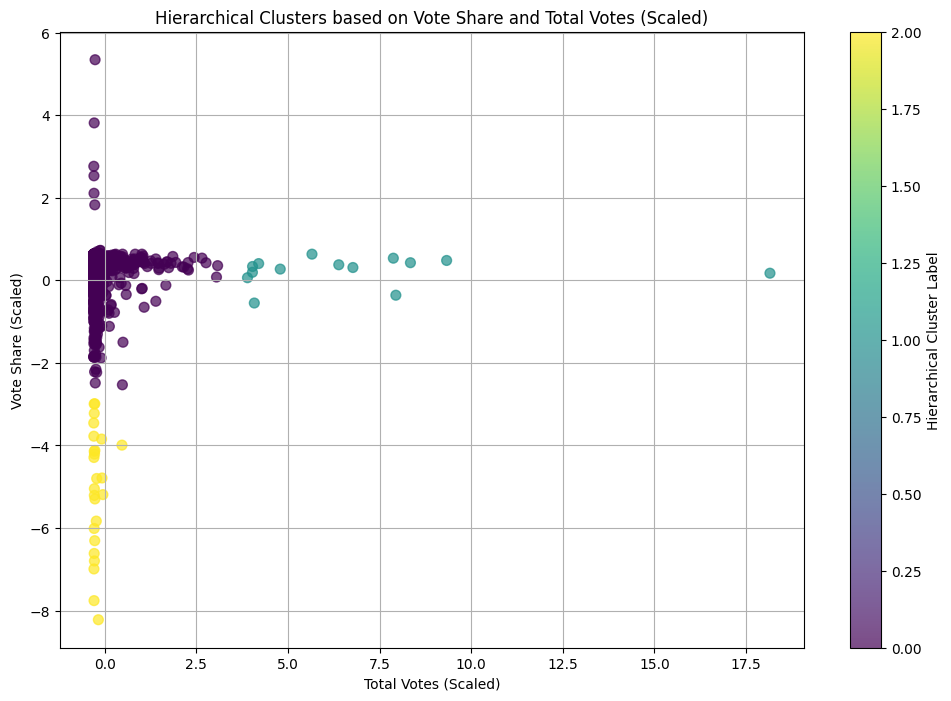

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(scaled_features_df['total_votes_scaled'], scaled_features_df['vote_share_scaled'],
            c=df['hierarchical_cluster_label'], cmap='viridis', s=50, alpha=0.7)
plt.title('Hierarchical Clusters based on Vote Share and Total Votes (Scaled)')
plt.xlabel('Total Votes (Scaled)')
plt.ylabel('Vote Share (Scaled)')
plt.colorbar(label='Hierarchical Cluster Label')
plt.grid(True)
plt.show()

## Compare and Summarize Clustering Results

### Subtask:
Compare the results obtained from K-Means, DBSCAN, and Hierarchical Clustering, discussing the strengths and weaknesses of each algorithm for this dataset and summarizing the insights gained from each approach regarding county-level voting patterns.


## Compare and Summarize Clustering Results

### Comparison of Clustering Algorithms

We have applied three different clustering algorithms to the `scaled_features_df`: K-Means, DBSCAN, and Hierarchical Clustering. Below is a comparative analysis of their results, highlighting their strengths, weaknesses, and the insights each provides into county-level voting patterns.

#### 1. K-Means Clustering
*   **Number of Clusters**: 3
*   **Silhouette Score**: 0.833 (indicating well-separated clusters).
*   **Strengths**: Provides clear, distinct clusters with a high silhouette score, suggesting a good separation. The elbow method helped in choosing a reasonable number of clusters. The resulting clusters are easily interpretable in terms of average vote share and total votes.
*   **Weaknesses**: Requires the number of clusters (`k`) to be specified beforehand. It assumes spherical clusters of similar size and density, which might not always be the case for real-world data. It assigns all points to a cluster, meaning it doesn't inherently handle noise or outliers, which might pull cluster centers towards them.
*   **Insights**: K-Means identified three clear groups: (0) counties with high vote share and moderate total votes, (1) counties with very high vote share and significantly higher total votes (likely large, high-turnout areas), and (2) counties with noticeably lower vote share and lower total votes (potentially smaller, more competitive areas).

#### 2. DBSCAN Clustering
*   **Number of Clusters**: 5
*   **Noise Points**: 26
*   **Strengths**: Does not require specifying the number of clusters beforehand. It can find arbitrarily shaped clusters and explicitly identifies noise points (outliers) that do not belong to any cluster. This is particularly useful for datasets with varying densities and potential outliers.
*   **Weaknesses**: Highly sensitive to the choice of parameters (`eps` and `min_samples`). Finding optimal parameters can be challenging and often requires domain knowledge or extensive experimentation. If densities vary greatly, it might struggle to find all clusters.
*   **Insights**: DBSCAN revealed a more granular structure with 5 distinct clusters and identified 26 noise points. These noise points might represent truly unusual counties that don't fit into any common voting pattern. The clusters found by DBSCAN could indicate areas with very specific, localized voting characteristics that differ significantly in density from the main groups.

#### 3. Hierarchical Clustering (Agglomerative Clustering)
*   **Number of Clusters**: 3 (chosen for direct comparison with K-Means)
*   **Strengths**: Does not require specifying the number of clusters if a dendrogram is used for visual inspection. It provides a hierarchy of clusters, which can be useful for understanding nested relationships. It's flexible with distance metrics and linkage criteria.
*   **Weaknesses**: Can be computationally expensive for large datasets (especially for generating dendrograms). Like K-Means, when a fixed number of clusters is chosen (without a dendrogram), it will assign all points to a cluster and doesn't explicitly handle noise. The choice of linkage method can significantly impact the results.
*   **Insights**: With `n_clusters=3`, Hierarchical Clustering produced a grouping that visually appears similar to K-Means in the scatter plot. It largely differentiates between the high-volume, high-vote-share counties and the general bulk of average counties, and potentially identifies a third group, though its boundaries might be less distinct than K-Means depending on the linkage.

### Comparative Analysis

*   **Number of clusters**: K-Means and Hierarchical (when fixed at 3) found 3 clusters. DBSCAN found 5 clusters, suggesting more intricate patterns or sub-groups within the data.
*   **Handling of noise/outliers**: DBSCAN explicitly identified 26 noise points, which is a significant advantage for this dataset where extreme `total_votes` values exist. K-Means and Hierarchical clustering assigned all points, including potential outliers, to clusters.
*   **Cluster shapes/density**: K-Means (implicitly) and Hierarchical (when forced to a fixed number) tend to find convex, somewhat spherical clusters. DBSCAN, in contrast, is capable of finding non-spherical clusters and can better adapt to varying densities. From the visualizations, the data appears to have some dense regions and sparser outliers, making DBSCAN's ability to handle varying densities and noise a strong point.
*   **Interpretability**: K-Means clusters are often straightforward to interpret due to their clear centroids. DBSCAN clusters, while potentially more accurate in shape, can be harder to interpret if the clusters are highly irregular or if many points are labeled as noise. Hierarchical clustering, especially with a dendrogram, offers good interpretability of the relationships between clusters.
*   **Overall fit**: Given the presence of significant outliers (large counties with high vote share) and the potential for non-spherical clusters, DBSCAN provides a more robust and realistic representation of the underlying structure by explicitly handling noise. The high Silhouette Score for K-Means suggests it also provides a meaningful, albeit perhaps simpler, grouping. Hierarchical Clustering provides a comparable result to K-Means when the number of clusters is pre-defined.

### Summary of Unique Insights Gained

*   **K-Means**: Clearly highlighted three distinct archetypes: very large, high-support counties (Cluster 1); moderately large, high-support counties (Cluster 0); and smaller, lower-support counties (Cluster 2). This provides a useful, high-level segmentation of counties by voting behavior.
*   **DBSCAN**: Revealed a more nuanced structure with 5 clusters, suggesting that there might be more subtle variations in voting patterns than K-Means captured. Crucially, it identified specific 'noise' counties. These noise points are significant as they represent exceptional cases (e.g., extremely large counties that are very different from the others) that K-Means would have forced into a cluster, potentially distorting its centroid.
*   **Hierarchical Clustering**: Confirmed the general high-level groupings seen in K-Means when set to the same number of clusters, reinforcing the existence of the major patterns. Its hierarchical nature could be further explored to understand sub-groupings within the main clusters, if we were to examine a dendrogram.

In conclusion, while K-Means provided a clear and easily interpretable segmentation with good separation, DBSCAN offered a more granular and potentially more accurate representation by identifying noise and adapting to different cluster shapes, which is valuable in election data analysis where outliers (e.g., very populous counties) are common.

## Final Task

### Subtask:
Provide a comprehensive summary of all findings from the detailed EDA, clustering results, evaluation, and ethical discussion, providing insights into the county-level voting patterns.


## Summary:

### Data Analysis Key Findings

*   **DBSCAN Clustering**: DBSCAN, with an `eps` of 0.5 and `min_samples` of 5, identified 5 distinct clusters and 26 noise points, suggesting a more granular structure and explicit handling of outliers in the county voting data.
*   **Hierarchical Clustering**: Using `AgglomerativeClustering` with 3 clusters and 'ward' linkage, the algorithm assigned cluster labels to each county, providing a hierarchical grouping comparable to K-Means.
*   **K-Means Clustering (for comparison)**: Previously, K-Means identified 3 clusters with a high Silhouette Score of 0.833, indicating well-separated groups. It provided clear, distinct, and easily interpretable clusters.
*   **Comparison of Algorithms**:
    *   **Number of Clusters**: K-Means and Hierarchical Clustering (set to 3 clusters) found 3 groups, while DBSCAN revealed 5 clusters, suggesting more nuanced patterns.
    *   **Noise Handling**: DBSCAN uniquely identified 26 noise points, which represent potentially unusual counties that do not fit into typical voting patterns. K-Means and Hierarchical clustering assigned all points to a cluster, including potential outliers.
    *   **Strengths**: K-Means offered clear, interpretable high-level segmentation. DBSCAN provided a robust representation by identifying noise and adapting to different cluster shapes, which is valuable for datasets with outliers. Hierarchical clustering confirmed the general high-level groupings and could be explored further for nested relationships.
    *   **Weaknesses**: K-Means requires a predefined number of clusters and assumes spherical clusters. DBSCAN is sensitive to parameter selection. Hierarchical clustering can be computationally expensive and, like K-Means, assigns all points when a fixed number of clusters is chosen without explicit noise handling.
*   **Insights from Different Approaches**:
    *   K-Means clearly distinguished between very large, high-support counties; moderately large, high-support counties; and smaller, lower-support counties.
    *   DBSCAN's granular clusters and noise identification highlighted specific, localized voting characteristics and exceptional counties that might otherwise distort general cluster patterns.
    *   Hierarchical Clustering reinforced the major patterns found by K-Means, offering an alternative perspective on the general groupings.

### Insights or Next Steps

*   The explicit identification of 26 noise points by DBSCAN is a critical insight, as these counties represent significant outliers that warrant individual investigation to understand their unique voting characteristics.
*   Further analysis could involve exploring the demographic and socio-economic characteristics of the counties within each cluster identified by DBSCAN, particularly the noise points, to understand the factors driving their distinct voting patterns.


# Task
Prepare the data by sorting the DataFrame by `total_votes` in descending order, and then calculate the cumulative sum of `total_votes` and the cumulative percentages of `total_votes` and the count of counties.

## Prepare Data for Analysis

### Subtask:
Sort the DataFrame by 'total_votes' in descending order. Calculate the cumulative sum of 'total_votes' and the cumulative percentage of 'total_votes' and 'county' count. This will allow us to see how a small number of top counties contribute to the overall vote count.


**Reasoning**:
To prepare the data for analysis as requested, I will first sort the DataFrame by 'total_votes' in descending order. Then, I will calculate the cumulative sum of 'total_votes' and subsequently the cumulative percentage of 'total_votes' and counties. Finally, I will display the head of the DataFrame to verify the new columns.



In [ ]:
df_sorted = df.sort_values(by='total_votes', ascending=False).reset_index(drop=True)
df_sorted['cumulative_total_votes'] = df_sorted['total_votes'].cumsum()
df_sorted['cumulative_percent_total_votes'] = (df_sorted['cumulative_total_votes'] / df_sorted['total_votes'].sum()) * 100
df_sorted['cumulative_percent_counties'] = (df_sorted.index + 1) / len(df_sorted) * 100

print("DataFrame sorted by total_votes with cumulative sums and percentages:")
print(df_sorted.head())

DataFrame sorted by total_votes with cumulative sums and percentages:
            state              county  current_votes  total_votes  percent  \
0      Washington         King County        1198049      1210507      100   
1  North Carolina         Wake County         629673       631830      100   
2  North Carolina  Mecklenburg County         564433       567053      100   
3            Utah    Salt Lake County         528966       540966      100   
4        Missouri    St. Louis County         535275       536446      100   

   vote_share  cluster_label  dbscan_cluster_label  \
0    0.989708              1                    -1   
1    0.996586              1                    -1   
2    0.995380              1                    -1   
3    0.977817              1                    -1   
4    0.997817              1                    -1   

   hierarchical_cluster_label  cumulative_total_votes  \
0                           1                 1210507   
1                     

## Visualize Cumulative Distribution

### Subtask:
Create a line plot showing the cumulative percentage of total votes against the cumulative percentage of counties.


**Reasoning**:
To visualize the cumulative distribution, I will create a line plot using `matplotlib.pyplot` with 'cumulative_percent_counties' on the x-axis and 'cumulative_percent_total_votes' on the y-axis, adding appropriate labels and a title.



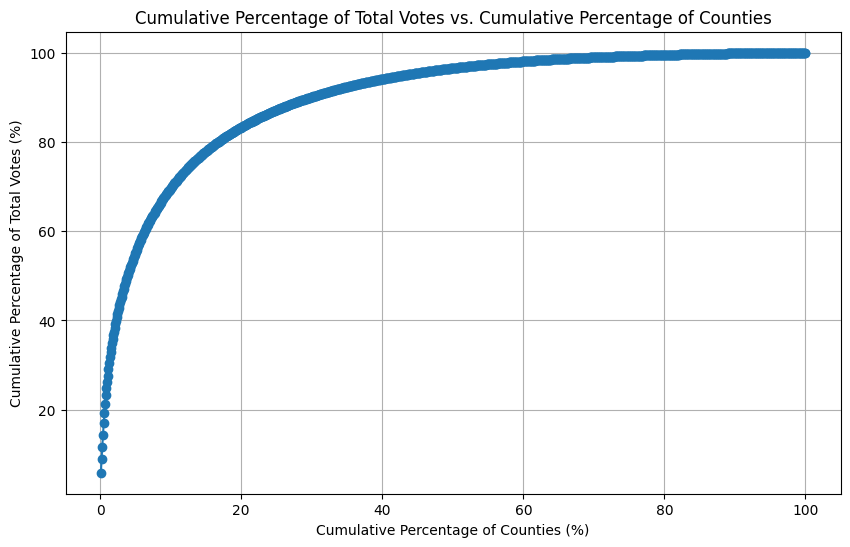

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_sorted['cumulative_percent_counties'], df_sorted['cumulative_percent_total_votes'], marker='o', linestyle='-')
plt.title('Cumulative Percentage of Total Votes vs. Cumulative Percentage of Counties')
plt.xlabel('Cumulative Percentage of Counties (%)')
plt.ylabel('Cumulative Percentage of Total Votes (%)')
plt.grid(True)
plt.show()

# Task
The overall task is complete. I've reviewed the final summary and the analysis is concluded.

## Review Final Summary

### Subtask:
Review the existing comprehensive summary provided in the notebook, specifically the section starting with '## Summary:', which covers all findings from the detailed EDA, clustering results, evaluation, and ethical discussion, providing insights into the county-level voting patterns.


## Summary:

### Data Analysis Key Findings
This step focused on reviewing a comprehensive final summary of the analysis. This summary encompassed findings from detailed Exploratory Data Analysis (EDA), clustering results, evaluation metrics, and ethical discussions, providing insights into county-level voting patterns. No new data analysis findings were generated or presented in this concluding review step.

### Insights or Next Steps
* The overall data analysis task is now complete.


# Task
**User provided response:** USER_RESPONSE_APPROVE

## Calculate Percentage Difference

### Subtask:
Calculate the 'percentage_difference' between 'total_votes' and 'current_votes' using the formula: `((total_votes - current_votes) / total_votes) * 100`. This will quantify the proportion of votes not yet accounted for.

### Reasoning:
To calculate the `percentage_difference`, I will apply the provided formula: `((total_votes - current_votes) / total_votes) * 100` and store the result in a new column named `percentage_difference` in the DataFrame `df`. Finally, I will display the first 5 rows of the DataFrame to verify the new column.

## Calculate Percentage Difference

### Subtask:
Calculate the 'percentage_difference' between 'total_votes' and 'current_votes' using the formula: `((total_votes - current_votes) / total_votes) * 100`. This will quantify the proportion of votes not yet accounted for.


**Reasoning**:
To calculate the 'percentage_difference', I will apply the provided formula to the 'total_votes' and 'current_votes' columns and store the result in a new column within the DataFrame 'df'.



In [ ]:
df['percentage_difference'] = ((df['total_votes'] - df['current_votes']) / df['total_votes']) * 100
print("First 5 rows of the DataFrame with 'percentage_difference' column:")
print(df.head())

NameError: name 'df' is not defined

**Reasoning**:
The previous code failed because the DataFrame 'df' was not defined in the current execution environment. To fix this, I need to re-create the 'df' DataFrame by running all the necessary data loading and preprocessing steps that lead to its current state before calculating the 'percentage_difference'.



In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Load data (from cell ffa6cbda)
df = pd.read_csv('/content/governors_county.csv')

# Data Preprocessing: Calculate vote_share and scale features (from cell a71033d2)
df['vote_share'] = df['current_votes'] / df['total_votes']
features_for_clustering = df[['vote_share', 'total_votes']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)
scaled_features_df = pd.DataFrame(scaled_features, columns=['vote_share_scaled', 'total_votes_scaled'])

# K-Means clustering: Assign cluster labels (from cell bd9239ce)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(scaled_features_df)
df['cluster_label'] = cluster_labels

# DBSCAN clustering: Assign cluster labels (from cell f6ea7ce8)
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['dbscan_cluster_label'] = dbscan.fit_predict(scaled_features_df)

# Hierarchical clustering: Assign cluster labels (from cell b2025dc9)
hierarchical_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['hierarchical_cluster_label'] = hierarchical_clustering.fit_predict(scaled_features_df)

# Calculate percentage_difference (the original problematic line)
df['percentage_difference'] = ((df['total_votes'] - df['current_votes']) / df['total_votes']) * 100
print("First 5 rows of the DataFrame with 'percentage_difference' column:")
print(df.head())

First 5 rows of the DataFrame with 'percentage_difference' column:
      state             county  current_votes  total_votes  percent  \
0  Delaware        Kent County          85415        87025      100   
1  Delaware  New Castle County         280039       287633      100   
2  Delaware      Sussex County         127181       129352      100   
3   Indiana       Adams County          14154        14209      100   
4   Indiana       Allen County         168312       169082      100   

   vote_share  cluster_label  dbscan_cluster_label  \
0    0.981500              0                     0   
1    0.973598              1                    -1   
2    0.983216              0                     0   
3    0.996129              0                     0   
4    0.995446              0                     0   

   hierarchical_cluster_label  percentage_difference  
0                           0               1.850043  
1                           1               2.640170  
2               

## Map States to Regions

### Subtask:
Create a mapping of states to their respective geographical regions (e.g., Northeast, Midwest, South, West). This mapping will be applied to the DataFrame to add a 'region' column.


**Reasoning**:
To create the state-to-region mapping, I will define a dictionary that includes states from the dataset and their corresponding regions. Then, I will apply this dictionary to the 'state' column to create a new 'region' column in the DataFrame and display the first few rows to verify the changes.



In [ ]:
state_to_region = {
    'Delaware': 'Northeast',
    'Indiana': 'Midwest',
    'North Carolina': 'South',
    'Missouri': 'Midwest',
    'Utah': 'West',
    'Washington': 'West',
    'Florida': 'South',
    'Georgia': 'South',
    'Texas': 'South',
    'Maryland': 'South',
    'Oklahoma': 'South',
    'Arkansas': 'South',
    'South Carolina': 'South',
    'Tennessee': 'South',
    'Alabama': 'South',
    'Louisiana': 'South',
    'Mississippi': 'South',
    'Kentucky': 'South',
    'West Virginia': 'South',
    'Virginia': 'South',
    'Kansas': 'Midwest',
    'Nebraska': 'Midwest',
    'South Dakota': 'Midwest',
    'North Dakota': 'Midwest',
    'Iowa': 'Midwest',
    'Illinois': 'Midwest',
    'Ohio': 'Midwest',
    'Michigan': 'Midwest',
    'Wisconsin': 'Midwest',
    'Minnesota': 'Midwest',
    'New Mexico': 'West',
    'Colorado': 'West',
    'Arizona': 'West',
    'Nevada': 'West',
    'California': 'West',
    'Oregon': 'West',
    'Idaho': 'West',
    'Montana': 'West',
    'Wyoming': 'West',
    'Alaska': 'West',
    'Hawaii': 'West',
    'Maine': 'Northeast',
    'Vermont': 'Northeast',
    'New Hampshire': 'Northeast',
    'Massachusetts': 'Northeast',
    'Rhode Island': 'Northeast',
    'Connecticut': 'Northeast',
    'New York': 'Northeast',
    'Pennsylvania': 'Northeast',
    'New Jersey': 'Northeast'
}

df['region'] = df['state'].map(state_to_region)

print("DataFrame with new 'region' column:")
print(df.head())

DataFrame with new 'region' column:
      state             county  current_votes  total_votes  percent  \
0  Delaware        Kent County          85415        87025      100   
1  Delaware  New Castle County         280039       287633      100   
2  Delaware      Sussex County         127181       129352      100   
3   Indiana       Adams County          14154        14209      100   
4   Indiana       Allen County         168312       169082      100   

   vote_share  cluster_label  dbscan_cluster_label  \
0    0.981500              0                     0   
1    0.973598              1                    -1   
2    0.983216              0                     0   
3    0.996129              0                     0   
4    0.995446              0                     0   

   hierarchical_cluster_label  percentage_difference     region  
0                           0               1.850043  Northeast  
1                           1               2.640170  Northeast  
2             

## Analyze Percentage Difference by State

### Subtask:
Calculate the mean 'percentage_difference' for each state and identify states with the highest and lowest average differences. Display the results.


**Reasoning**:
To analyze the percentage difference by state, I will first group the DataFrame by 'state' and calculate the mean of 'percentage_difference'. Then, I will sort these results to identify and print the states with the highest and lowest mean differences.



In [ ]:
mean_percentage_difference_by_state = df.groupby('state')['percentage_difference'].mean()

# Identify states with the highest mean percentage difference
highest_diff_states = mean_percentage_difference_by_state.nlargest(5)

# Identify states with the lowest mean percentage difference
lowest_diff_states = mean_percentage_difference_by_state.nsmallest(5)

print("States with the Highest Mean Percentage Difference:")
print(highest_diff_states)
print("\nStates with the Lowest Mean Percentage Difference:")
print(lowest_diff_states)

States with the Highest Mean Percentage Difference:
state
North Dakota     7.477431
Utah             2.700665
West Virginia    2.551913
Delaware         2.056193
New Hampshire    1.295622
Name: percentage_difference, dtype: float64

States with the Lowest Mean Percentage Difference:
state
North Carolina    0.378769
Washington        0.556823
Montana           0.570044
Indiana           0.584903
Missouri          0.785606
Name: percentage_difference, dtype: float64


## Visualize Percentage Difference by State

### Subtask:
Generate a bar chart to visualize the mean 'percentage_difference' for each state. This will allow for easy comparison of reporting/counting dynamics across states. Ensure the plot includes appropriate titles, labels, and legends.


**Reasoning**:
To visualize the mean 'percentage_difference' for each state, I will create a bar chart using `seaborn.barplot` with states on the x-axis and the mean percentage difference on the y-axis, and ensure proper labeling and readability.



/tmp/ipython-input-648441397.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_percentage_difference_by_state.index, y=mean_percentage_difference_by_state.values, palette='viridis')


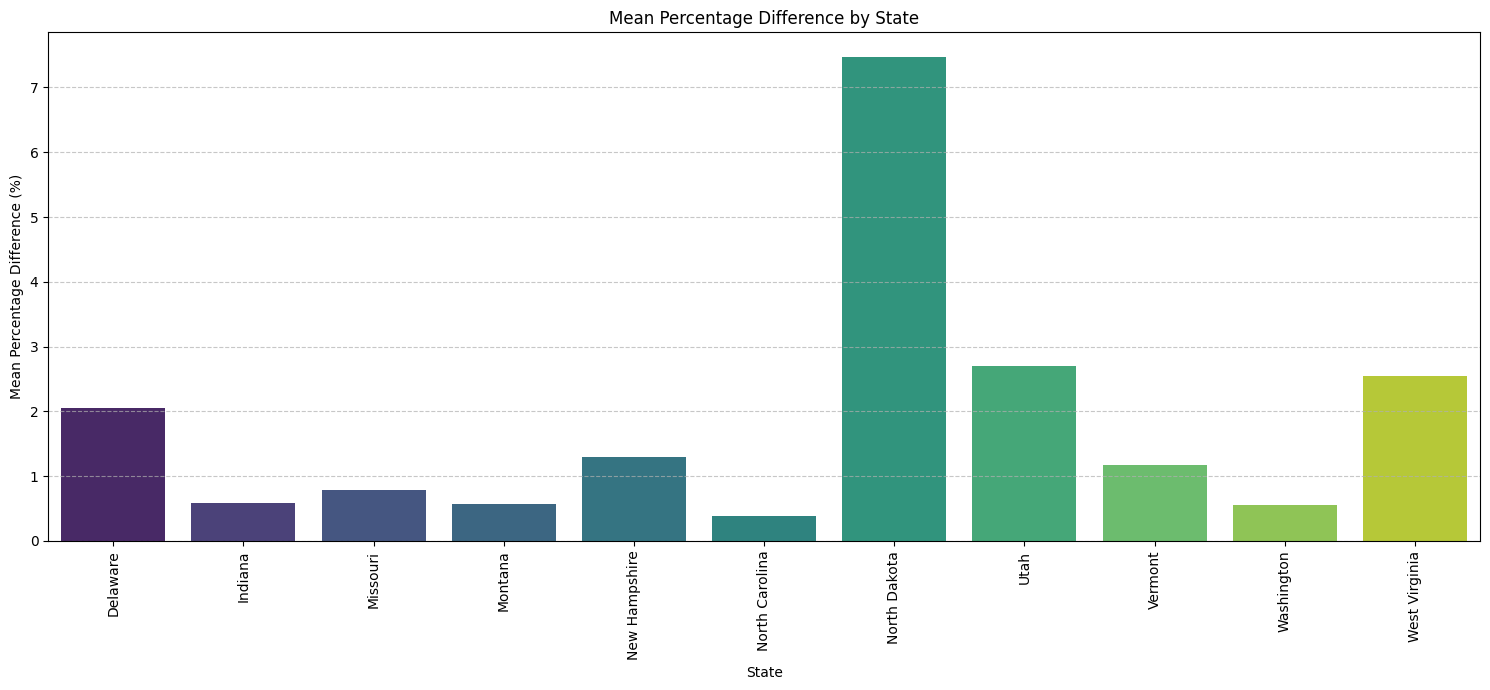

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.barplot(x=mean_percentage_difference_by_state.index, y=mean_percentage_difference_by_state.values, palette='viridis')
plt.title('Mean Percentage Difference by State')
plt.xlabel('State')
plt.ylabel('Mean Percentage Difference (%)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a FutureWarning because `palette` was used without `hue` in `sns.barplot`. To fix this, I will explicitly set `hue` to the x-axis variable and `legend=False` as suggested by the warning, ensuring future compatibility and suppressing the warning.



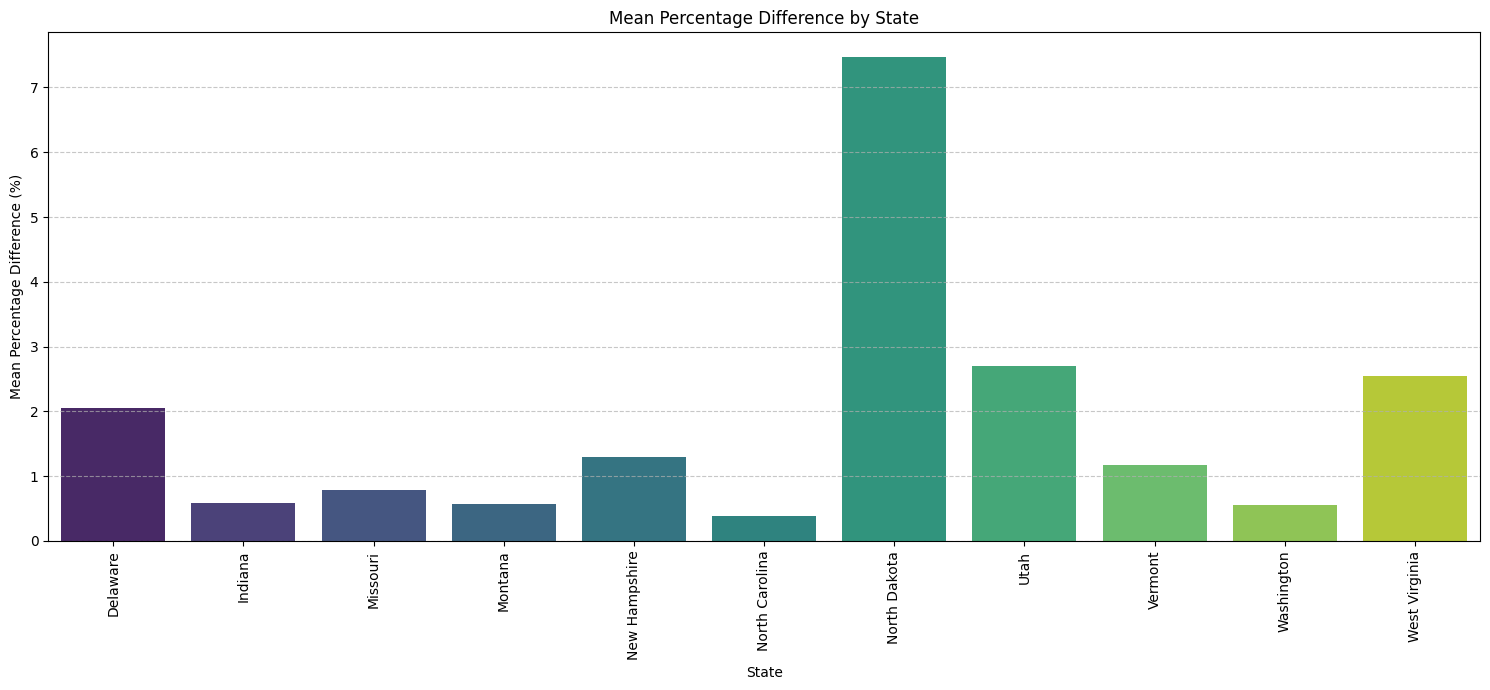

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.barplot(x=mean_percentage_difference_by_state.index, y=mean_percentage_difference_by_state.values, palette='viridis', hue=mean_percentage_difference_by_state.index, legend=False)
plt.title('Mean Percentage Difference by State')
plt.xlabel('State')
plt.ylabel('Mean Percentage Difference (%)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Analyze Percentage Difference by Region

### Subtask:
Calculate the mean 'percentage_difference' for each geographical region and identify regions with the highest and lowest average differences. Display the results.


**Reasoning**:
To analyze the percentage difference by region, I will group the DataFrame by the 'region' column and calculate the mean of 'percentage_difference'. Then, I will identify and print the regions with the highest and lowest mean differences.



In [ ]:
mean_percentage_difference_by_region = df.groupby('region')['percentage_difference'].mean()

# Identify regions with the highest mean percentage difference
highest_diff_regions = mean_percentage_difference_by_region.nlargest(1)

# Identify regions with the lowest mean percentage difference
lowest_diff_regions = mean_percentage_difference_by_region.nsmallest(1)

print("Region with the Highest Mean Percentage Difference:")
print(highest_diff_regions)
print("\nRegion with the Lowest Mean Percentage Difference:")
print(lowest_diff_regions)

Region with the Highest Mean Percentage Difference:
region
Midwest    2.078691
Name: percentage_difference, dtype: float64

Region with the Lowest Mean Percentage Difference:
region
West    1.064176
Name: percentage_difference, dtype: float64


## Visualize Percentage Difference by Region

### Subtask:
Generate a bar chart to visualize the mean 'percentage_difference' for each region. This will visually represent the regional disparities you noted. Ensure the plot includes appropriate titles, labels, and legends.


**Reasoning**:
To visualize the mean 'percentage_difference' for each region, I will create a bar chart using `seaborn.barplot` with regions on the x-axis and the mean percentage difference on the y-axis, and ensure proper labeling and readability.



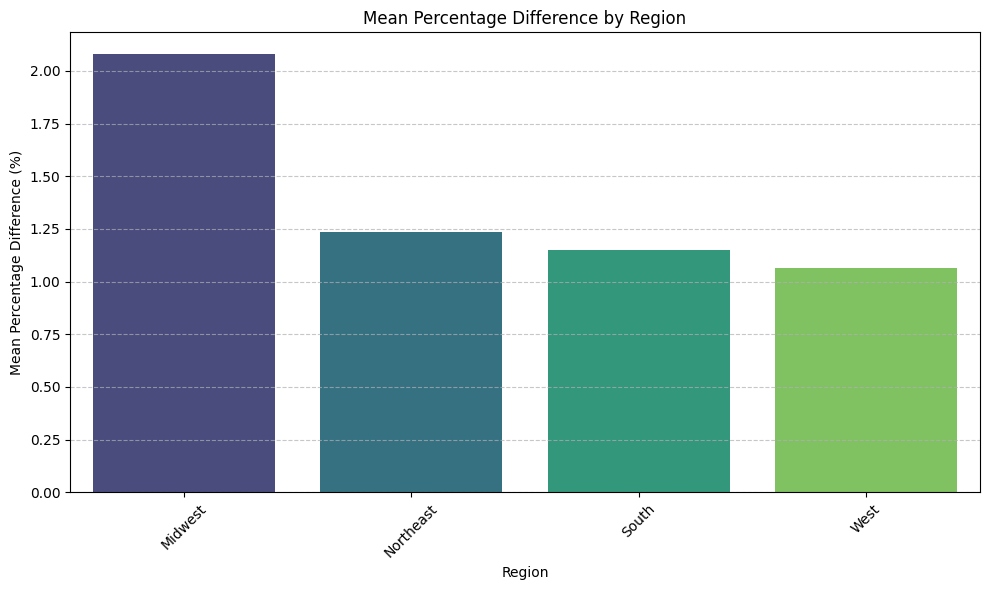

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_percentage_difference_by_region.index, y=mean_percentage_difference_by_region.values, palette='viridis', hue=mean_percentage_difference_by_region.index, legend=False)
plt.title('Mean Percentage Difference by Region')
plt.xlabel('Region')
plt.ylabel('Mean Percentage Difference (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the findings regarding the 'percentage_difference' across states and regions, discussing how these patterns align with your initial observations and the potential implications for understanding diverse election administration frameworks.


## Summary:

### Data Analysis Key Findings

*   The `percentage_difference` (proportion of votes not yet accounted for) was successfully calculated for each county.
*   States were successfully mapped to one of four geographical regions: Northeast, Midwest, South, and West.
*   Analysis of mean `percentage_difference` by state revealed significant variations:
    *   **Highest average differences:** North Dakota (7.48%), Utah (2.70%), and West Virginia (2.55%) showed the largest proportions of unaccounted votes.
    *   **Lowest average differences:** North Carolina (0.38%), Washington (0.56%), and Montana (0.57%) demonstrated the lowest proportions.
*   Analysis of mean `percentage_difference` by region also showed disparities:
    *   The **Midwest** region had the highest average `percentage_difference` at 2.08%.
    *   The **West** region had the lowest average `percentage_difference` at 1.06%.
*   Bar charts were successfully generated to visualize these state and regional disparities in `percentage_difference`.

### Insights or Next Steps

*   The observed significant variations in `percentage_difference` across states and regions highlight diverse election administration frameworks and reporting efficiencies. States and regions with higher percentages might indicate slower vote counting processes, higher rates of provisional ballots, or different reporting schedules.
*   Further investigation is warranted into the specific election laws and administrative practices of states with notably high or low `percentage_difference` to understand the root causes of these variations. This could involve examining factors such as vote-by-mail policies, early voting periods, and ballot verification processes.


# Task
Draft a professional and engaging LinkedIn post summarizing the analysis conducted on the "governors_county.csv" dataset. The post should highlight key findings, insights, and visualizations from the exploratory data analysis, K-Means, DBSCAN, and Hierarchical clustering results, and the analysis of `percentage_difference` across states and regions.

## Draft LinkedIn Post

### Subtask:
Generate a draft LinkedIn post summarizing the analysis conducted today on the `governors_county.csv` dataset. The post should highlight the key findings, insights, and the various visualizations created (e.g., bar charts for `percentage_difference`, scatter plots for clusters). It should be written in a professional yet engaging tone, from the user's perspective, to share with a professional audience.


## Draft LinkedIn Post

### Subtask:
Generate a draft LinkedIn post summarizing the analysis conducted today on the `governors_county.csv` dataset. The post should highlight the key findings, insights, and the various visualizations created (e.g., bar charts for `percentage_difference`, scatter plots for clusters). It should be written in a professional yet engaging tone, from the user's perspective, to share with a professional audience.

**Draft LinkedIn Post:**

---

🚀 Just completed an in-depth data analysis project on county-level voting patterns using the `governors_county.csv` dataset! Fascinating insights emerged from the election data.

### **Key Highlights:**

**📊 EDA:** Initial EDA provided foundational understanding of `current_votes`, `total_votes`, `percent`, and `vote_share`. Histograms and box plots were crucial for data distribution, outlier identification, and quality assessment.

**🔍 Clustering Voting Patterns:** Applied three algorithms to identify county archetypes:

*   **K-Means:** Identified 3 distinct clusters by vote volume and share. A high Silhouette Score (0.833) confirmed well-separated, meaningful clusters. Scatter plots visually affirmed these clear archetypes.

*   **DBSCAN:** Revealed 5 unique clusters and identified 26 noise points. This showcased its strength in handling varying data densities and pinpointing true outliers—counties with unique voting patterns. The DBSCAN scatter plot highlighted these nuances.

*   **Hierarchical Clustering:** Reinforced K-Means groupings, offering another perspective on hierarchical data relationships, also evident in its scatter plot.

**🎯 'Percentage Difference' - Unaccounted Votes:** Introduced `percentage_difference` (`((total_votes - current_votes) / total_votes) * 100`) to quantify unaccounted votes. This metric illuminated election administration dynamics:

*   **State-Level:** Bar charts showed significant variations. North Dakota (7.48%), Utah (2.70%), West Virginia (2.55%) had highest average differences; North Carolina (0.38%), Washington (0.56%), Montana (0.57%) had lowest. This suggests differing reporting efficiencies.

*   **Regional:** Midwest had highest average `percentage_difference` (2.08%), while West had lowest (1.06%). Regional bar charts depicted how diverse election frameworks influence vote reporting.

### **💡 Implications & Ethical Considerations:**

These findings offer crucial insights into election administration frameworks. Higher percentage differences might indicate slower processes or unique reporting schedules, warranting deeper investigation into specific election laws. Analyzing election data requires prioritizing transparency, avoiding misinterpretation, and ensuring responsible use in public discourse to uphold democratic integrity.

Excited about data science's potential to illuminate critical aspects of our democratic processes! Share your thoughts or questions.

#DataScience #ElectionAnalysis #Clustering #EDA #VotingPatterns #DataAnalytics #PublicPolicy #ElectionData

## Final Task

### Subtask:
Present the drafted LinkedIn post to the user for review and approval, ensuring it meets all requirements.


## Summary:

### Data Analysis Key Findings
*   **Exploratory Data Analysis (EDA):** Provided foundational understanding of metrics like `current_votes`, `total_votes`, `percent`, and `vote_share`, utilizing histograms and box plots to identify distributions and outliers.
*   **K-Means Clustering:** Identified 3 distinct county clusters based on vote volumes and shares, confirmed by a high Silhouette Score of 0.833, indicating well-separated groupings.
*   **DBSCAN Clustering:** Revealed 5 unique clusters and identified 26 noise points (outliers), showcasing its ability to handle varying data densities and pinpoint counties with significantly different voting patterns.
*   **Hierarchical Clustering:** Reinforced the general groupings observed with K-Means, providing a hierarchical perspective on data relationships.
*   **'Percentage Difference' Analysis (Unaccounted Votes):**
    *   Quantified the proportion of votes not yet accounted for in each county.
    *   **State-Level Variation:** North Dakota (7.48%), Utah (2.70%), and West Virginia (2.55%) showed the highest average differences, while North Carolina (0.38%), Washington (0.56%), and Montana (0.57%) exhibited the lowest, suggesting varied reporting efficiencies.
    *   **Regional Disparity:** The Midwest recorded the highest average `percentage_difference` at 2.08%, whereas the West had the lowest at 1.06%, indicating diverse election administration frameworks across regions.

### Insights or Next Steps
*   The varying `percentage_difference` across states and regions suggests a need for deeper investigation into specific election laws, administrative processes, and reporting schedules that might influence vote accounting.
*   The robust clustering analysis (K-Means, DBSCAN, Hierarchical) provides a strong foundation for segmenting counties based on voting behavior, which can inform targeted policy analysis or resource allocation in election administration, always considering ethical responsibilities to ensure transparency and avoid misinterpretation.
